## Question 1

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



In [2]:
df = pd.read_excel("Diabetes_Data.xlsx")
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)


In [3]:
corr_matrix = df.corr()


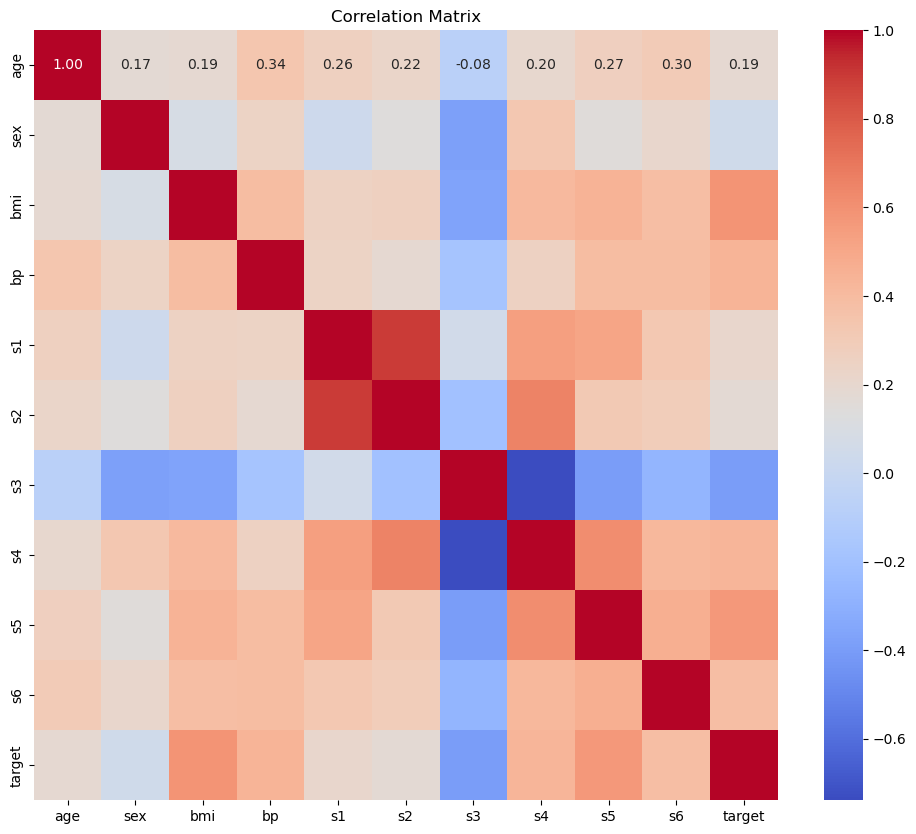

In [4]:
df["target"] = diabetes.target

corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


In [ ]:



diabetes = load_diabetes()


X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Dependent variable
y = diabetes.target


X_const = sm.add_constant(X)


model = sm.OLS(y, X_const).fit()

# Predictions
y_pred = model.predict(X_const)

# Mean Squared Error
mse = mean_squared_error(y, y_pred)

# Adjusted R-squared
adj_r2 = model.rsquared_adj


print("Mean Squared Error (MSE):", mse)
print("Adjusted R-squared:", adj_r2)


print(model.summary())


Mean Squared Error (MSE): 2859.69634758675
Adjusted R-squared: 0.5065592904853231
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        18:13:48   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [ ]:



diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target


remaining_features = set(X.columns)
selected_features = []
current_score = -np.inf

while remaining_features:
    scores_with_candidates = []
    for feature in remaining_features:
        # Try adding feature
        features_to_test = selected_features + [feature]
        lr = LinearRegression().fit(X[features_to_test], y)
        score = r2_score(y, lr.predict(X[features_to_test]))
        scores_with_candidates.append((score, feature))

    
    scores_with_candidates.sort(reverse=True)
    best_new_score, best_feature = scores_with_candidates[0]

    if best_new_score > current_score:
        remaining_features.remove(best_feature)
        selected_features.append(best_feature)
        current_score = best_new_score
    else:
        break

print("Selected features:", selected_features)


lr_final = LinearRegression().fit(X[selected_features], y)
y_pred = lr_final.predict(X[selected_features])

print("MSE:", mean_squared_error(y, y_pred))
print("R2:", r2_score(y, y_pred))


Selected features: ['bmi', 's5', 'bp', 's1', 'sex', 's2', 's4', 's6', 's3', 'age']
MSE: 2859.69634758675
R2: 0.5177484222203499


QUESTION 2

In [ ]:
import pandas as pd


df = pd.read_csv("titanic3.csv")

# Keep relevant columns
df = df[['survived', 'pclass', 'sex', 'age']]


df = df.dropna()

# Overall survival probability
survival_prob = df['survived'].mean()
print("Overall probability of survival:", survival_prob)


Overall probability of survival: 0.40822179732313574


QUESTION 2.3

In [ ]:

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 40, 60, 100],
    labels=['Child', 'Young Adult', 'Adult', 'Senior']
)


table = df.groupby(['pclass', 'sex', 'age_group'])['survived'].mean().reset_index()

print(table)


    pclass     sex    age_group  survived
0        1  female        Child  0.923077
1        1  female  Young Adult  0.971429
2        1  female        Adult  0.977273
3        1  female       Senior  0.833333
4        1    male        Child  0.750000
5        1    male  Young Adult  0.406250
6        1    male        Adult  0.312500
7        1    male       Senior  0.066667
8        2  female        Child  0.952381
9        2  female  Young Adult  0.893939
10       2  female        Adult  0.812500
11       2  female       Senior       NaN
12       2    male        Child  0.523810
13       2    male  Young Adult  0.097087
14       2    male        Adult  0.035714
15       2    male       Senior  0.166667
16       3  female        Child  0.534483
17       3  female  Young Adult  0.451220
18       3  female        Adult  0.272727
19       3  female       Senior  1.000000
20       3    male        Child  0.208333
21       3    male  Young Adult  0.174274
22       3    male        Adult  0

/tmp/ipykernel_242058/1633623212.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(['pclass', 'sex', 'age_group'])['survived'].mean().reset_index()


QUESTION 2.4

In [ ]:
import statsmodels.api as sm

# Encode sex
df['sex'] = df['sex'].map({'male': 0, 'female': 1})


X = df[['pclass', 'sex', 'age']]
y = df['survived']


X = sm.add_constant(X)


logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.469897
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                 1046
Model:                          Logit   Df Residuals:                     1042
Method:                           MLE   Df Model:                            3
Date:                Sun, 11 Jan 2026   Pseudo R-squ.:                  0.3051
Time:                        18:13:48   Log-Likelihood:                -491.51
converged:                       True   LL-Null:                       -707.31
Covariance Type:            nonrobust   LLR p-value:                 3.167e-93
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0919      0.371      5.633      0.000       1.364       2.820
pclass        -1.1332      0.

QUESTION 2.5

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# these are probabilities which are going to be predicted
df['pred_prob'] = logit_model.predict(X)

# am classfying using 0.5
df['predicted'] = (df['pred_prob'] >= 0.5).astype(int)


cm = confusion_matrix(y, df['predicted'])
accuracy = accuracy_score(y, df['predicted'])

print("Confusion Matrix:\n", cm)
print("Classification Accuracy:", accuracy)


Confusion Matrix:
 [[523  96]
 [126 301]]
Classification Accuracy: 0.7877629063097514


QUESTION 3.3

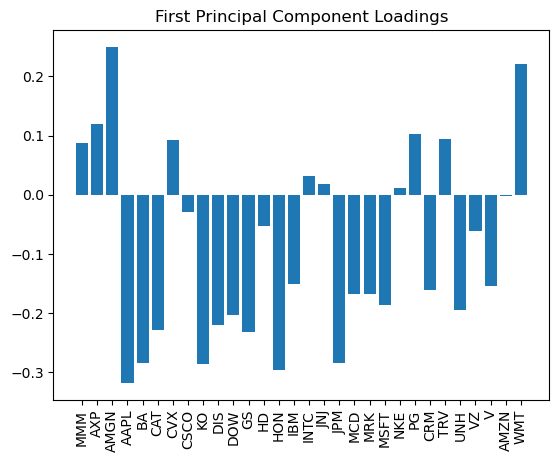

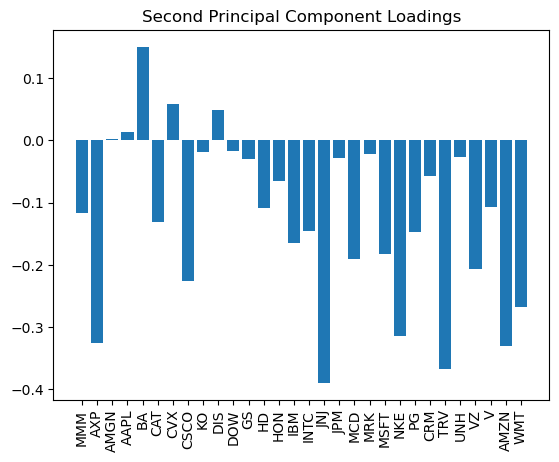

In [ ]:

# Dow Jones tickers
tickers = [
    'MMM','AXP','AMGN','AAPL','BA','CAT','CVX','CSCO','KO','DIS','DOW','GS',
    'HD','HON','IBM','INTC','JNJ','JPM','MCD','MRK','MSFT','NKE','PG','CRM',
    'TRV','UNH','VZ','V','AMZN','WMT'
]


data = yf.download(
    tickers,
    start="2020-01-01",
    end="2021-01-01",
    progress=False
)

# Use Close prices 
prices = data['Close']


returns = prices.pct_change().dropna()


corr_matrix = returns.corr()


pca = PCA()
pca.fit(corr_matrix)
components = pca.components_

# this is the First principal component
plt.figure()
plt.bar(tickers, components[0])
plt.xticks(rotation=90)
plt.title("First Principal Component Loadings")
plt.show()

# this is the Second principal component
plt.figure()
plt.bar(tickers, components[1])
plt.xticks(rotation=90)
plt.title("Second Principal Component Loadings")
plt.show()


QUESTION 3.4

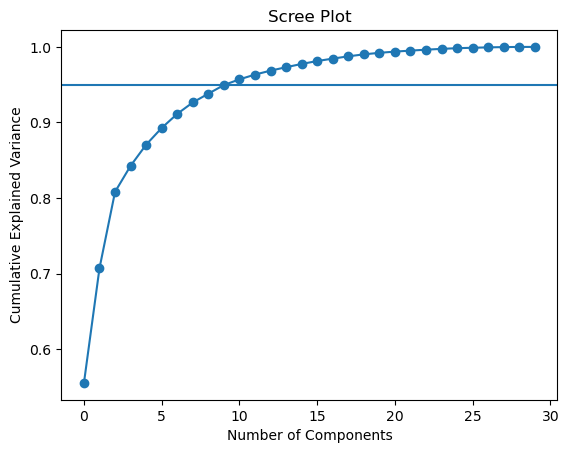

11

In [ ]:

explained_variance = pca.explained_variance_ratio_

# Scree plot
plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.axhline(y=0.95)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.show()

# those are Number of components for 95% variance
num_components_95 = np.argmax(np.cumsum(explained_variance) >= 0.95) + 1
num_components_95


QUESTION 3.5

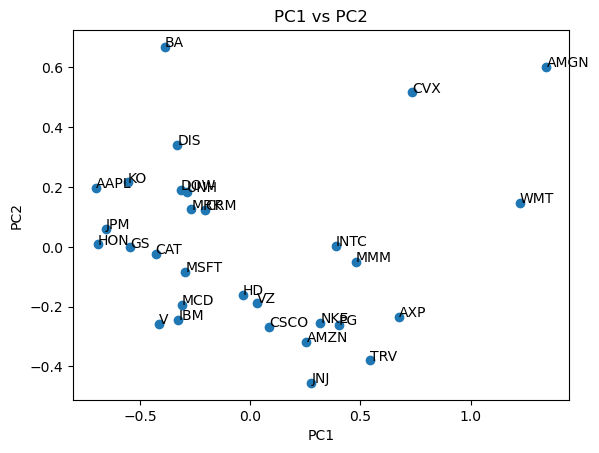

AMGN    1.504919
WMT     1.367034
CVX     1.001910
dtype: float64

In [ ]:

pc_scores = pca.transform(corr_matrix)


plt.figure()
plt.scatter(pc_scores[:, 0], pc_scores[:, 1])

for i, ticker in enumerate(tickers):
    plt.text(pc_scores[i, 0], pc_scores[i, 1], ticker)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2")
plt.show()

mean_point = pc_scores.mean(axis=0)
distances = np.linalg.norm(pc_scores - mean_point, axis=1)

outliers = pd.Series(distances, index=tickers).sort_values(ascending=False)
outliers.head(3)
